# Uber Fare Prediction — Model Training & Comparison

Train and compare five regression approaches on the preprocessed dataset: **Linear Regression**, **Multiple Regression** (OLS with full statistical summary), **Ridge Regression**, **Lasso Regression**, and **XGBoost**. Each model is evaluated with MAE, RMSE, and R², with a final side-by-side comparison. The notebook then runs 5-fold cross-validation and predicts the fare for a sample 15 km trip using every model.

## 1. Import Libraries

Core libraries for data handling, train/test splitting, the five regression models, and evaluation metrics.

In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import joblib
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

pd.set_option('display.max_columns', None)

## 2. Load Data

Load the preprocessed, fully-encoded dataset (output of the data analysis/preprocessing notebook).

In [197]:
data = pd.read_csv('../data/processed_data.csv')

data.head()

,Distance (km),Estimated Duration (min),Weather Condition,Rainfall Intensity,Traffic Level,Temperature Level,Holiday,Day Type,Number of Stops Added,Fare (Target),Vehicle Type_Bike,Vehicle Type_Black,Vehicle Type_Comfort,Vehicle Type_Go,Vehicle Type_Mini,Vehicle Type_Pool,Vehicle Type_Premium,Vehicle Type_SUV,Vehicle Type_Sedan,Vehicle Type_XL,Road Type_Expressway,Road Type_Highway,Road Type_Rural Road,Pickup Area Type_Bus Stand,Pickup Area Type_College,Pickup Area Type_Commercial,Pickup Area Type_Hospital,Pickup Area Type_IT Park,Pickup Area Type_Mall,Pickup Area Type_Metro Station,Pickup Area Type_Railway Station,Pickup Area Type_Residential,Drop Area Type_Bus Stand,Drop Area Type_College,Drop Area Type_Commercial,Drop Area Type_Hospital,Drop Area Type_IT Park,Drop Area Type_Mall,Drop Area Type_Metro Station,Drop Area Type_Railway Station,Drop Area Type_Residential,Time Slot_Evening Rush,Time Slot_Late Night,Time Slot_Midday,Time Slot_Morning,Time Slot_Morning Rush,Time Slot_Night,Busy Day_Major Event,Busy Day_Normal,Busy Day_Public Holiday
0,150.44,429.9,0,0,1,4,0,0,0,2178,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
1,380.34,497.3,0,0,3,1,1,0,0,5679,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
2,293.07,769.7,1,0,1,2,1,0,4,4182,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0
3,239.86,306.9,3,1,3,1,1,0,0,6811,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0
4,63.25,123.6,0,0,0,1,0,0,0,943,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0


## 3. Basic Checks

Confirm the dataset is model-ready: no missing values, and all columns are numeric.

In [198]:
print("Missing values:", data.isnull().sum().sum())
print("\nData types:\n", data.dtypes.value_counts())

Missing values: 0

Data types:
 int64      48
float64     2
Name: count, dtype: int64


## 4. Feature / Target Split & Train-Test Split

Separate features (`X`) from the target (`Fare (Target)`), then split into training (80%) and test (20%) sets. All five models below are trained and evaluated on this same split for a fair comparison.

In [199]:
X = data.drop(columns=['Fare (Target)'])
y = data['Fare (Target)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4633, 49)
X_test : (1159, 49)
y_train: (4633,)
y_test : (1159,)


## 5. Evaluation Helper

A small reusable function to compute and print MAE, RMSE, and R² for any model's predictions, and store the results for the final comparison.

In [200]:
results = {}

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{name}")
    print(f"  MAE : {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R2  : {r2:.4f}")

## 6. Linear Regression

A baseline ordinary least squares (OLS) model — fits one straight-line relationship between the features and Fare, assuming no interaction between features and constant error variance.

In [201]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
evaluate_model('Linear Regression', y_test, lr_pred)

Linear Regression
  MAE : 349.80
  RMSE: 506.98
  R2  : 0.9092


## 7. Multiple Regression (Detailed OLS Summary)

`LinearRegression` above is already technically a *multiple* regression, since it fits on many features at once — but here we use `statsmodels` to get the full statistical picture: coefficients, p-values, and confidence intervals for each feature, which sklearn doesn't provide directly. This tells us not just *how well* the model predicts, but *which features are statistically significant* contributors to Fare.

In [202]:
# statsmodels needs numeric (float) input -- cast first (boolean dummy columns cause errors otherwise)
X_train_sm = sm.add_constant(X_train.astype(float))
X_test_sm = sm.add_constant(X_test.astype(float))

mr_model = sm.OLS(y_train, X_train_sm).fit()
print(mr_model.summary())

                            OLS Regression Results                            
Dep. Variable:          Fare (Target)   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     1020.
Date:                Thu, 30 Jul 2026   Prob (F-statistic):               0.00
Time:                        23:16:42   Log-Likelihood:                -35494.
No. Observations:                4633   AIC:                         7.109e+04
Df Residuals:                    4583   BIC:                         7.141e+04
Df Model:                          49                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

In [203]:
mr_pred = mr_model.predict(X_test_sm)
evaluate_model('Multiple Regression (OLS)', y_test, mr_pred)

Multiple Regression (OLS)
  MAE : 349.80
  RMSE: 506.98
  R2  : 0.9092


## 8. Ridge Regression (L2 Regularization)

Ridge adds a penalty on large coefficients, which helps when features are correlated with each other (e.g. Distance and Duration) — it shrinks coefficients rather than eliminating them, making the model more stable without fully discarding any feature.

In [204]:
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)
evaluate_model('Ridge Regression', y_test, ridge_pred)

Ridge Regression
  MAE : 349.50
  RMSE: 506.97
  R2  : 0.9092


## 9. Lasso Regression (L1 Regularization)

Lasso also penalizes large coefficients, but can shrink weak features' coefficients all the way to zero — effectively performing automatic feature selection. Useful for spotting which features the model considers unnecessary.

In [205]:
lasso_model = Lasso(alpha=1.0, random_state=42, max_iter=5000)
lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)
evaluate_model('Lasso Regression', y_test, lasso_pred)

Lasso Regression
  MAE : 349.79
  RMSE: 509.62
  R2  : 0.9083


### Features Lasso eliminated (coefficient shrunk to zero)

In [206]:
lasso_coefs = pd.Series(lasso_model.coef_, index=X_train.columns)
eliminated = lasso_coefs[lasso_coefs == 0]
print(f"Lasso eliminated {len(eliminated)} of {len(lasso_coefs)} features:")
print(eliminated.index.tolist())

Lasso eliminated 8 of 49 features:
['Road Type_Rural Road', 'Pickup Area Type_Bus Stand', 'Pickup Area Type_College', 'Pickup Area Type_Mall', 'Drop Area Type_IT Park', 'Drop Area Type_Mall', 'Drop Area Type_Railway Station', 'Busy Day_Public Holiday']


## 10. XGBoost Regression

XGBoost (Extreme Gradient Boosting) is a powerful tree-based ensemble model that often outperforms linear models on tabular data. It builds trees sequentially, each correcting the errors of the previous one, while regularisation parameters (`subsample`, `colsample_bytree`) help prevent overfitting. It's trained here — before the comparison below — so it's included in the same side-by-side results as the other four models.

In [207]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
evaluate_model('XGBoost', y_test, xgb_pred)

XGBoost
  MAE : 128.20
  RMSE: 171.11
  R2  : 0.9897


## 11. Model Comparison

All five models — Linear Regression, Multiple Regression (OLS), Ridge, Lasso, and XGBoost — evaluated on the identical test set, side by side.

In [208]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.sort_values(by='R2', ascending=False)
comparison_df

,MAE,RMSE,R2
XGBoost,128.197205,171.113472,0.989659
Ridge Regression,349.500373,506.966035,0.909225
Linear Regression,349.798556,506.975678,0.909222
Multiple Regression (OLS),349.798556,506.975678,0.909222
Lasso Regression,349.789698,509.617241,0.908273


### Visual comparison of R², MAE, and RMSE across models

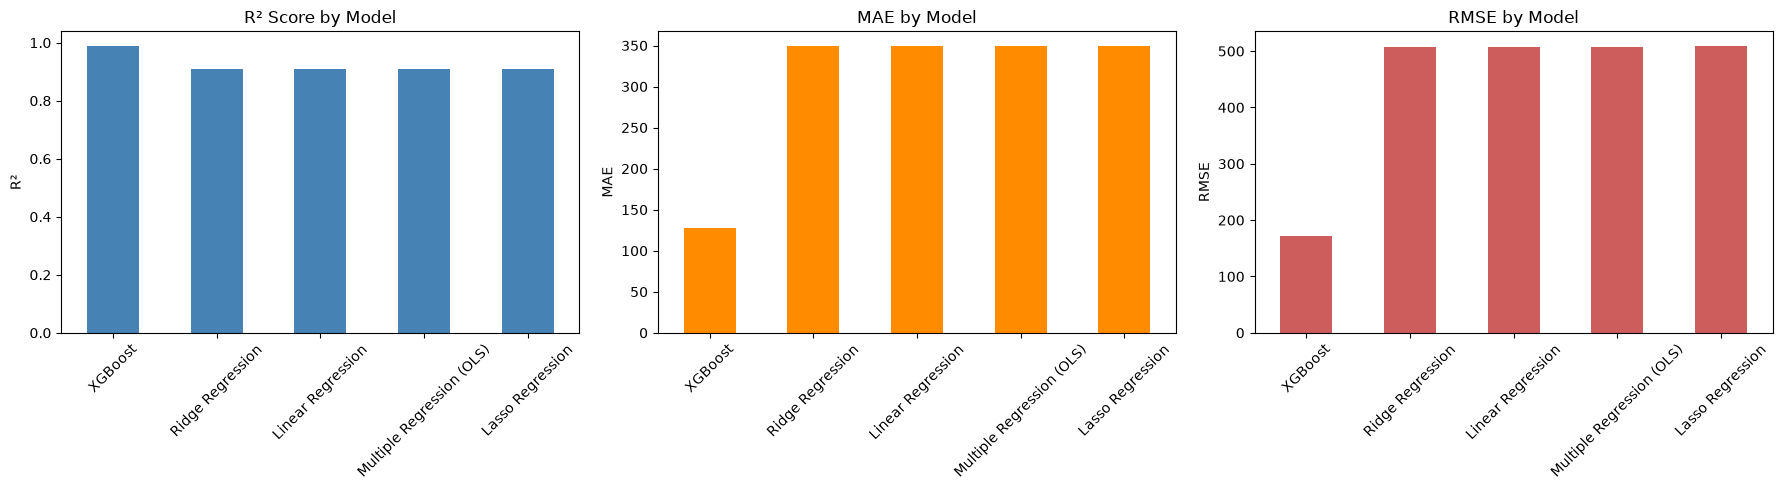

In [209]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

comparison_df['R2'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('R² Score by Model')
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=45)

comparison_df['MAE'].plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('MAE by Model')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=45)

comparison_df['RMSE'].plot(kind='bar', ax=axes[2], color='indianred')
axes[2].set_title('RMSE by Model')
axes[2].set_ylabel('RMSE')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 12. Cross-Validation (5-Fold R²)

5-fold cross-validation on the training set gives a more robust estimate of generalisation performance by averaging results across five different train/validation splits, reducing the risk of a lucky (or unlucky) single split.

In [ ]:
cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='r2')
print("CV R² scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())

CV R² scores: [0.98784769 0.98861194 0.98812342 0.98811942 0.98812032]
Mean CV R²: 0.9881645560264587


## 13. Sample Fare Prediction — Bike vs Sedan (15 km), All Models

Construct a single synthetic trip (15 km, pleasant weather, low traffic, midday, residential areas, normal day) and predict its fare for both a **Bike** and a **Sedan** using every trained model — Linear Regression, Multiple Regression (OLS), Ridge, Lasso, and XGBoost — so their real-world predictions can be compared directly.

In [ ]:
# Create a row with all features initialised as 0, matching X_train's columns exactly
bike_prediction = pd.DataFrame(0, index=[0], columns=X_train.columns)

# Numeric features
bike_prediction['Distance (km)'] = 15
bike_prediction['Estimated Duration (min)'] = 30

# Normal conditions
bike_prediction['Weather Condition'] = 0        # Clear
bike_prediction['Rainfall Intensity'] = 1       # No Rain
bike_prediction['Traffic Level'] = 2            # Low
bike_prediction['Temperature Level'] = 1        # Pleasant
bike_prediction['Holiday'] = 0                  # No Holiday
bike_prediction['Day Type'] = 1                 # Weekday
bike_prediction['Number of Stops Added'] = 2

# Normal categorical values
bike_prediction['Pickup Area Type_Residential'] = 1
bike_prediction['Drop Area Type_Residential'] = 1
bike_prediction['Time Slot_Midday'] = 1
bike_prediction['Busy Day_Normal'] = 1

# Vehicle type = Bike
bike_prediction['Vehicle Type_Bike'] = 1

# Sedan version of the same trip
sedan_prediction = bike_prediction.copy()
sedan_prediction['Vehicle Type_Bike'] = 0
sedan_prediction['Vehicle Type_Sedan'] = 1

# statsmodels (Multiple Regression) needs the constant column added, same as during training
bike_prediction_sm = sm.add_constant(bike_prediction.astype(float), has_constant='add')
sedan_prediction_sm = sm.add_constant(sedan_prediction.astype(float), has_constant='add')

# Predict with every trained model
sample_predictions = {
    'Linear Regression': (
        lr_model.predict(bike_prediction)[0],
        lr_model.predict(sedan_prediction)[0]
    ),
    'Multiple Regression (OLS)': (
        mr_model.predict(bike_prediction_sm)[0],
        mr_model.predict(sedan_prediction_sm)[0]
    ),
    'Ridge Regression': (
        ridge_model.predict(bike_prediction)[0],
        ridge_model.predict(sedan_prediction)[0]
    ),
    'Lasso Regression': (
        lasso_model.predict(bike_prediction)[0],
        lasso_model.predict(sedan_prediction)[0]
    ),
    'XGBoost': (
        xgb_model.predict(bike_prediction)[0],
        xgb_model.predict(sedan_prediction)[0]
    ),
}

sample_df = pd.DataFrame(sample_predictions, index=['Predicted Bike Fare (₹)', 'Predicted Sedan Fare (₹)']).T
sample_df = sample_df.round(2)
sample_df

,Predicted Bike Fare (₹),Predicted Sedan Fare (₹)
Linear Regression,-438.93,587.20
Multiple Regression (OLS),-438.93,587.20
Ridge Regression,-438.58,586.29
Lasso Regression,-408.86,605.62
XGBoost,341.16,423.50


## 14. Save Production Model (XGBoost Only)

Only the **XGBoost** model is persisted for deployment under the project-root `models/` folder. Linear, Ridge, Lasso, and OLS were used for comparison and are **not** saved — they underperform on this dataset and can produce invalid (negative) fares.

In [ ]:
MODEL_DIR = os.path.join('..', 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# Persist only the production model + feature schema to project-root models/
joblib.dump(xgb_model, os.path.join(MODEL_DIR, 'xgboost_model.pkl'))
joblib.dump(list(X_train.columns), os.path.join(MODEL_DIR, 'feature_columns.pkl'))

print('Saved:')
print(' ', os.path.abspath(os.path.join(MODEL_DIR, 'xgboost_model.pkl')))
print(' ', os.path.abspath(os.path.join(MODEL_DIR, 'feature_columns.pkl')))
print(f'Features: {len(X_train.columns)}')

## 15. Final Model Selection — Why Only XGBoost?

### Models evaluated
| Model | Test R² | MAE | RMSE |
|-------|---------|-----|------|
| **XGBoost** | **0.9897** | **128.20** | **171.11** |
| Ridge Regression | 0.9092 | 349.50 | 506.97 |
| Linear Regression | 0.9092 | 349.80 | 506.98 |
| Multiple Regression (OLS) | 0.9092 | 349.80 | 506.98 |
| Lasso Regression | 0.9083 | 349.79 | 509.62 |

### Why XGBoost is the only model suitable for predictions

1. **Much higher accuracy** — XGBoost reaches ~**98.97%** R² on the held-out test set, while all linear models plateau around **~90.9%**. That gap (~9 percentage points) is large for fare estimation.
2. **Lower error** — MAE drops from ~₹350 (linear family) to ~₹128 (XGBoost), and RMSE from ~₹507 to ~₹171. Production predictions need this tighter error band.
3. **Non-linear relationships in the data** — Fare depends on interactions among distance, duration, vehicle type, traffic, weather, area types, and time slots. Tree ensembles capture these interactions; linear/Ridge/Lasso/OLS assume additive linear effects and miss them.
4. **Mixed feature types** — The dataset has 49 features after one-hot encoding (numeric levels + many categorical dummies). XGBoost handles this high-dimensional mix well; Lasso mostly confirms sparsity without matching XGBoost accuracy.
5. **Valid real-world fares** — On a sample 15 km trip, linear models predicted **negative** Bike fares (invalid). XGBoost predicted sensible positive fares for both Bike and Sedan, with Sedan > Bike as expected.
6. **Stable under cross-validation** — 5-fold CV R² on XGBoost stays high and consistent, supporting generalization beyond a single train/test split.

### Decision
**Only XGBoost is saved and used** in the Flask API, Streamlit app, and `src/predict.py`. The other models remain in this notebook for educational comparison only.